In [1]:
library(edgeR)
library(csaw)
library(Rsamtools)
library(ggplot2)


Loading required package: limma



Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading 

In [2]:
peak.df <- read.table('/media/protein/fy2306/projects/base_editing/data/MYC-ChIP-20260721-bl/peaks/MB231_pool_equal_depth/MB231_pool_equal_depth_peaks.narrowPeak', sep='\t', header=FALSE)
colnames(peak.df) <- c('contig', 'start', 'stop', 'peak_name', 'score', 'strand', 'signal', 'logP', 'logQ', 'summit')
peak.df$peak_id <- peak.df$peak_name
standard.chr <- paste0("chr", c(1:22, "X", "Y"))
peak.df <- peak.df[peak.df$contig %in% standard.chr, ]
head(peak.df)


,contig,start,stop,peak_name,score,strand,signal,logP,logQ,summit,peak_id
,<chr>,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1121,chr1,184158,184515,MB231_pool_equal_depth_peak_1121,25,.,2.02813,2.59349,0.303091,312,MB231_pool_equal_depth_peak_1121
1122,chr1,186844,187114,MB231_pool_equal_depth_peak_1122,32,.,2.06654,3.26000,0.630507,200,MB231_pool_equal_depth_peak_1122
1123,chr1,190812,191062,MB231_pool_equal_depth_peak_1123,37,.,2.33819,3.79017,0.883994,188,MB231_pool_equal_depth_peak_1123
1124,chr1,191272,191504,MB231_pool_equal_depth_peak_1124,23,.,1.85916,2.35497,0.255669,69,MB231_pool_equal_depth_peak_1124
1125,chr1,778414,778610,MB231_pool_equal_depth_peak_1125,76,.,3.38021,7.69969,3.689660,128,MB231_pool_equal_depth_peak_1125
1126,chr1,790589,790796,MB231_pool_equal_depth_peak_1126,48,.,2.70417,4.89143,1.486450,131,MB231_pool_equal_depth_peak_1126


In [3]:
stat.df <- data.frame(
    name = c(
        "MB231_ctl_R1",
        "MB231_ctl_R2",
        "MB231_ASO723_R1",
        "MB231_ASO723_R2",
        "MB231_ASO723-2_R1",
        "MB231_ASO723-2_R2"
    ),
    treatment = c(
        "CTL",
        "CTL",
        "X723",
        "X723",
        "X723-2",
        "X723-2"
    ),
    stringsAsFactors = FALSE
)

stat.df$treatment <- factor(
    stat.df$treatment,
    levels = c("CTL", "X723", "X723-2")
)

stat.df

name,treatment
<chr>,<fct>
MB231_ctl_R1,CTL
MB231_ctl_R2,CTL
MB231_ASO723_R1,X723
MB231_ASO723_R2,X723
MB231_ASO723-2_R1,X723-2
MB231_ASO723-2_R2,X723-2


In [4]:
count.df <- read.csv('/media/protein/fy2306/projects/base_editing/data/MYC-ChIP-20260721-bl/peak_fragment_counts/MB231_pool_equal_depth_peaks_fragment_counts.tsv', sep='\t', check.names = FALSE)
count.df <- count.df[count.df$peak_id %in% peak.df$peak_id, ]
rownames(count.df) <- count.df$peak_id
count.df <- count.df[,grep('^MB231_', colnames(count.df))]
head(count.df)


,MB231_ctl_R1,MB231_ctl_R2,MB231_ASO723_R1,MB231_ASO723_R2,MB231_ASO723-2_R1,MB231_ASO723-2_R2
,<int>,<int>,<int>,<int>,<int>,<int>
MB231_pool_equal_depth_peak_1121,2,3,10,7,9,4
MB231_pool_equal_depth_peak_1122,6,5,11,6,6,6
MB231_pool_equal_depth_peak_1123,8,6,7,5,3,9
MB231_pool_equal_depth_peak_1124,7,4,6,7,5,6
MB231_pool_equal_depth_peak_1125,7,7,11,6,4,4
MB231_pool_equal_depth_peak_1126,1,5,4,7,4,8


In [5]:
count.meta <- peak.df[,c('peak_id', 'peak_name', 'score', 'logP')]
count.meta$coverage <- rowSums(count.df)
head(count.meta)


,peak_id,peak_name,score,logP,coverage
,<chr>,<chr>,<int>,<dbl>,<dbl>
1121,MB231_pool_equal_depth_peak_1121,MB231_pool_equal_depth_peak_1121,25,2.59349,35
1122,MB231_pool_equal_depth_peak_1122,MB231_pool_equal_depth_peak_1122,32,3.26000,40
1123,MB231_pool_equal_depth_peak_1123,MB231_pool_equal_depth_peak_1123,37,3.79017,38
1124,MB231_pool_equal_depth_peak_1124,MB231_pool_equal_depth_peak_1124,23,2.35497,35
1125,MB231_pool_equal_depth_peak_1125,MB231_pool_equal_depth_peak_1125,76,7.69969,39
1126,MB231_pool_equal_depth_peak_1126,MB231_pool_equal_depth_peak_1126,48,4.89143,29


In [6]:
## edgeR pipeline with csaw TMM normalization from 10 kbp genomic bins
## Reference: csaw Book Section 5.2, Eliminating composition biases
init.peak.pvalue.cutoff <- 0.15
init.coverage.cutoff <- 15

want.peaks <- subset(count.meta, coverage >= init.coverage.cutoff)
want.peaks <- subset(want.peaks, logP >= -log10(init.peak.pvalue.cutoff))

filtered.counts <- subset(count.df, rownames(count.df) %in% want.peaks$peak_id)

print(dim(want.peaks))
print(dim(filtered.counts))

sample.names <- colnames(filtered.counts)
stat.df <- stat.df[match(sample.names, stat.df$name),]
stopifnot(!any(is.na(stat.df$name)))
stopifnot(identical(sample.names, stat.df$name))

# csaw normalization
# https://bioconductor.org/books/3.13/csawBook/chap-norm.html
bam.dir <- '/media/protein/fy2306/projects/base_editing/data/MYC-ChIP-20260721-bl/bigwigs/tmp'
bam.files <- file.path(bam.dir, paste0(sample.names, '.IP.human.filteredbl.bam'))
names(bam.files) <- sample.names
stopifnot(all(file.exists(bam.files)))
stopifnot(all(file.exists(paste0(bam.files, '.bai'))))

param <- readParam(pe="both", max.frag = 400, restrict = standard.chr)
binned <- windowCounts(bam.files, bin=TRUE, width=10000, param=param)
csaw.norm.factors <- normFactors(binned, se.out=FALSE)
names(csaw.norm.factors) <- sample.names

csaw.lib.size <- binned$totals
names(csaw.lib.size) <- sample.names

[1] 437867      5
[1] 437867      6


In [7]:
dge <- DGEList(counts=filtered.counts, group=stat.df$treatment, lib.size=csaw.lib.size)
dge$samples$norm.factors <- csaw.norm.factors

# To keep using edgeR's original peak-count library sizes instead of csaw BAM totals,
# replace the two lines above with:
# dge <- DGEList(counts=filtered.counts, group=stat.df$treatment)
# dge$samples$norm.factors <- csaw.norm.factors

csaw.lib.size.df <- data.frame(
    sample=sample.names,
    treatment=stat.df$treatment,
    csaw_lib_size=csaw.lib.size,
    csaw_norm_factor=csaw.norm.factors,
    effective_lib_size=csaw.lib.size * csaw.norm.factors,
    row.names=NULL
)
write.table(
    csaw.lib.size.df,
    file=file.path(bam.dir, 'MB231_csaw_library_sizes.nobl.tsv'),
    sep='\t',
    quote=FALSE,
    row.names=FALSE
)
csaw.lib.size.df

design <- model.matrix(~ 0 + treatment, data=stat.df)
colnames(design) <- make.names(colnames(design))

contrasts <- makeContrasts(
  X723_vs_CTL = treatmentX723 - treatmentCTL,
  X723_2_vs_CTL = treatmentX723.2 - treatmentCTL,
  levels = design
)

dge <- estimateDisp(dge, design)
fit <- glmQLFit(dge, design)

x723.res <- glmQLFTest(fit, contrast=contrasts[,'X723_vs_CTL'])
x723_2.res <- glmQLFTest(fit, contrast=contrasts[,'X723_2_vs_CTL'])

x723.de <- topTags(x723.res, n=Inf)$table
x723_2.de <- topTags(x723_2.res, n=Inf)$table

print(dim(x723.de))
head(x723.de)


sample,treatment,csaw_lib_size,csaw_norm_factor,effective_lib_size
<chr>,<fct>,<int>,<dbl>,<dbl>
MB231_ctl_R1,CTL,27499892,0.9987735,27466164
MB231_ctl_R2,CTL,24746531,1.0007106,24764115
MB231_ASO723_R1,X723,31692214,1.0000125,31692609
MB231_ASO723_R2,X723,34890664,0.9994622,34871900
MB231_ASO723-2_R1,X723-2,22189458,1.0011758,22215548
MB231_ASO723-2_R2,X723-2,21159925,0.9998673,21157117


[1] 437867      5


,logFC,logCPM,F,PValue,FDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MB231_pool_equal_depth_peak_378873,4.306294,-1.5381694,27.65775,2.448730e-07,0.1072218
MB231_pool_equal_depth_peak_313972,-1.799209,-0.4772029,23.76851,1.615337e-06,0.2621001
MB231_pool_equal_depth_peak_313831,2.822474,-1.4927807,22.96108,2.396417e-06,0.2621001
MB231_pool_equal_depth_peak_409346,-2.095277,-1.1101754,22.32717,3.271368e-06,0.2621001
MB231_pool_equal_depth_peak_116220,-3.550073,-1.9811253,22.09626,3.661053e-06,0.2621001
MB231_pool_equal_depth_peak_49366,-2.108165,-1.1474949,21.64417,4.577026e-06,0.2621001


In [8]:
x723.de$peak_id <- rownames(x723.de)
x723_2.de$peak_id <- rownames(x723_2.de)
x723.de <- merge(x723.de, count.meta, by='peak_id', all.x=TRUE, sort=TRUE)
x723_2.de <- merge(x723_2.de, count.meta, by='peak_id', all.x=TRUE, sort=TRUE)
cn <- colnames(x723.de)
cn[8] <- 'MACS.score'
cn[9] <- 'MACS.logP'
colnames(x723.de) <- cn
colnames(x723_2.de) <- cn
head(x723.de)
head(x723_2.de)


,peak_id,logFC,logCPM,F,PValue,FDR,peak_name,MACS.score,MACS.logP,coverage
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>
1,MB231_pool_equal_depth_peak_10000,0.9888674,-1.916854,2.59268966,0.1082104,0.8963395,MB231_pool_equal_depth_peak_10000,16,1.66563,31
2,MB231_pool_equal_depth_peak_100000,0.4656277,-1.435941,0.86082601,0.3541124,0.9434098,MB231_pool_equal_depth_peak_100000,33,3.35263,48
3,MB231_pool_equal_depth_peak_100001,-0.3395444,-2.170630,0.22841321,0.6329851,0.9834901,MB231_pool_equal_depth_peak_100001,21,2.15924,24
4,MB231_pool_equal_depth_peak_100002,0.2007642,-1.387791,0.17161761,0.6789182,0.9863933,MB231_pool_equal_depth_peak_100002,48,4.89143,50
5,MB231_pool_equal_depth_peak_100003,-0.5191510,-1.668696,1.00564983,0.3166025,0.9251401,MB231_pool_equal_depth_peak_100003,19,1.92529,39
6,MB231_pool_equal_depth_peak_100004,-0.1741417,-2.131007,0.06397653,0.8004583,0.9863933,MB231_pool_equal_depth_peak_100004,21,2.15585,25


,peak_id,logFC,logCPM,F,PValue,FDR,peak_name,MACS.score,MACS.logP,coverage
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>
1,MB231_pool_equal_depth_peak_10000,0.04433556,-1.916854,0.00316268,0.9551828,0.9932720,MB231_pool_equal_depth_peak_10000,16,1.66563,31
2,MB231_pool_equal_depth_peak_100000,0.15150323,-1.435941,0.06772938,0.7948167,0.9885025,MB231_pool_equal_depth_peak_100000,33,3.35263,48
3,MB231_pool_equal_depth_peak_100001,0.26000720,-2.170630,0.13241456,0.7161494,0.9765127,MB231_pool_equal_depth_peak_100001,21,2.15924,24
4,MB231_pool_equal_depth_peak_100002,0.06211337,-1.387791,0.01287338,0.9097267,0.9897882,MB231_pool_equal_depth_peak_100002,48,4.89143,50
5,MB231_pool_equal_depth_peak_100003,-0.99103926,-1.668696,2.51525021,0.1136038,0.9200053,MB231_pool_equal_depth_peak_100003,19,1.92529,39
6,MB231_pool_equal_depth_peak_100004,0.26084232,-2.131007,0.13474899,0.7137679,0.9765127,MB231_pool_equal_depth_peak_100004,21,2.15585,25


In [9]:
## combine the results for plotting

x723.de$Contrast <- '723_vs_CTL'
x723_2.de$Contrast <- '723_2_vs_CTL'

dat.de <- rbind(x723.de, x723_2.de)
write.table(dat.de, '/media/scratch/fy2306/projects/base_editing/results/ChIP-Seq/MB231_all_contrasts.nobl.tsv', row.names=FALSE, sep='\t', quote=FALSE)

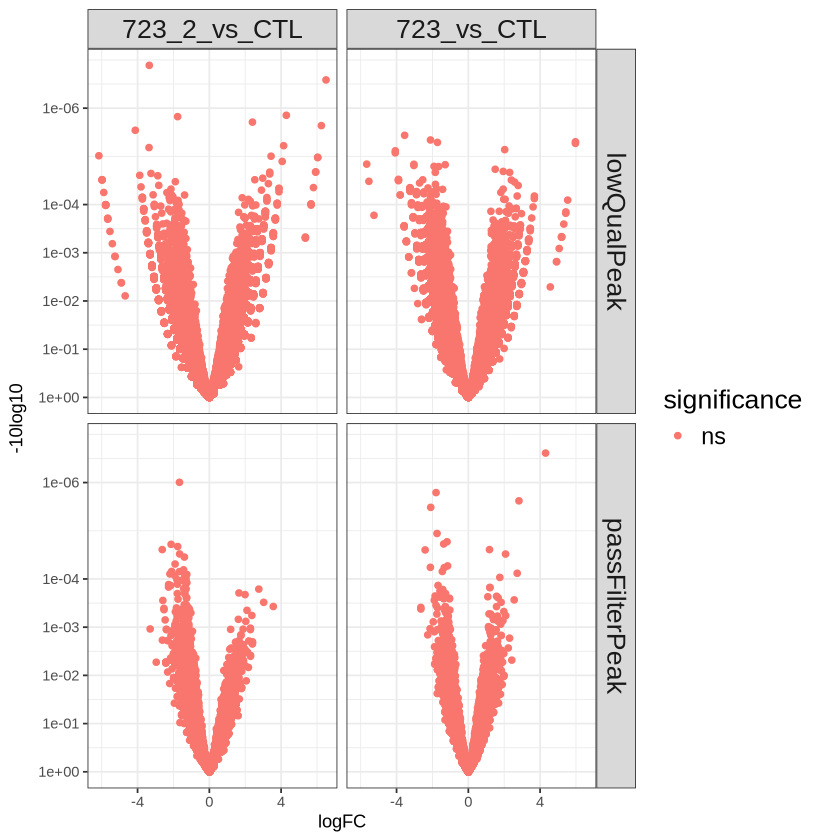

In [10]:
library(scales)

neg10log10 <- trans_new(
  "neg10log10",
  transform = function(x) -10*log10(x),
  inverse = function(x) 10^(-x/10)
)

dat.de$filter <- ifelse(dat.de$coverage >= 30 & dat.de$MACS.logP >= -log10(1e-05), 'passFilterPeak', 'lowQualPeak')
dat.de$significance <- ifelse(dat.de$FDR < 0.001, '***', ifelse(dat.de$FDR < 0.01, '**', ifelse(dat.de$FDR < 0.05, '*', 'ns')))
dat.de$significance[is.na(dat.de$significance)] <- 'filtered'
ggplot(dat.de) + geom_point(aes(x=logFC, y=PValue, color=significance)) + scale_y_continuous(trans = neg10log10, name = "-10log10", breaks=c(1, 0.1, 0.01, 0.001, 1e-4, 1e-6, 1e-8)) + 
  facet_grid(filter ~ Contrast) + theme_bw() + theme(strip.text=element_text(size=16), legend.text=element_text(size=14), legend.title=element_text(size=16))


Contrast_group,median_logFC,n,p.value,cdf_at_zero,label,y
<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<dbl>
723,-0.05116559,16671,9.468469e-40,0.5454982,median = -0.051 Wilcoxon p = 9.47e-40,0.8231778
723_2,-0.07761242,16671,4.617216e-85,0.5542559,median = -0.078 Wilcoxon p = 4.62e-85,0.6913706


Warning message:
“Removed 2329 rows containing non-finite outside the scale range
(`stat_density()`).”


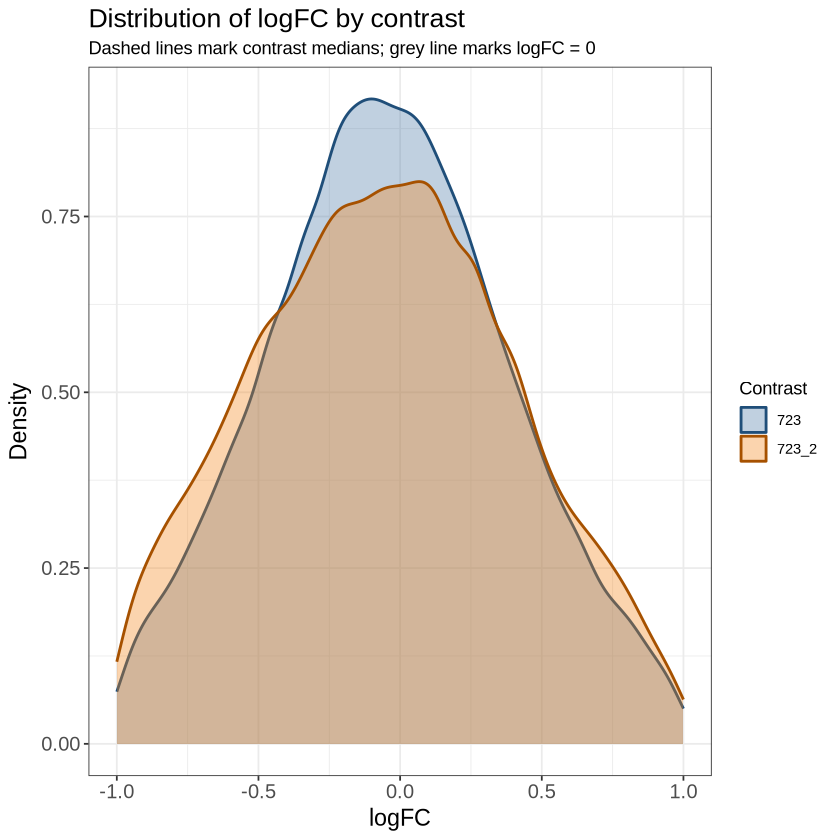

In [11]:
## plot logFC density and test whether the distribution is centered at zero

logfc.df <- subset(dat.de, is.finite(logFC) & !is.na(Contrast) & coverage >= 30 & MACS.logP >= -log10(1e-05))
logfc.df$Contrast_group <- factor(ifelse(grepl("723_2", logfc.df$Contrast), "723_2", "723"), levels = c("723", "723_2"))

logfc.summary <- do.call(rbind, lapply(split(logfc.df$logFC, logfc.df$Contrast_group), function(x) {
  wt <- wilcox.test(x, mu = 0, alternative = "less", exact = FALSE)
  data.frame(
    median_logFC = median(x),
    n = length(x),
    p.value = wt$p.value,
	cdf_at_zero = mean(x <= 0)
  )
} ))
logfc.summary$Contrast_group <- rownames(logfc.summary)
rownames(logfc.summary) <- NULL
logfc.summary$label <- sprintf("median = %.3f\nWilcoxon p = %.2e", logfc.summary$median_logFC, logfc.summary$p.value)

density.max <- do.call(rbind, lapply(split(logfc.df, logfc.df$Contrast_group), function(d) {
  den <- density(d$logFC, na.rm = TRUE)
  data.frame(Contrast_group = d$Contrast_group[1], y = max(den$y) * 0.95)
} ))
logfc.summary <- merge(logfc.summary, density.max, by = "Contrast_group", all.x = TRUE)

logfc.summary

ggplot(logfc.df, aes(x = logFC, fill = Contrast_group, color = Contrast_group, group = Contrast_group)) +
  geom_density(alpha = 0.35, linewidth = 0.8) +
  # geom_vline(xintercept = 0, color = "grey45", linewidth = 0.5) +
  # geom_vline(data = logfc.summary, aes(xintercept = median_logFC, color = Contrast_group), linetype = "dashed", linewidth = 0.8) +
  # geom_text(data = logfc.summary, aes(x = median_logFC, y = y, label = label), inherit.aes = FALSE, angle = 90, vjust = -0.4, hjust = 1, color = "#D55E00", size = 4) +
  scale_fill_manual(values = c("723" = "#4C78A8", "723_2" = "#F58518"), name = "Contrast") +
  scale_color_manual(values = c("723" = "#1F4E79", "723_2" = "#A65100"), name = "Contrast") +
  xlim(-1, 1) +
  labs(x = "logFC", y = "Density", title = "Distribution of logFC by contrast", subtitle = "Dashed lines mark contrast medians; grey line marks logFC = 0") +
  theme_bw() +
  theme(strip.text = element_text(size = 16), plot.title = element_text(size = 16), axis.text = element_text(size = 12), axis.title = element_text(size = 14))